# Piezometric Network of Catalonia — Groundwater Analysis

**Author:** Carlos Daniel Muñoz Sánchez  
**Data Source:** Catalan Water Agency (ACA) — Open Data  
**Dataset:** Groundwater piezometric level in Catalonia  
**URL:** https://analisi.transparenciacatalunya.cat/api/views/6899-hrme/rows.csv  
**License:** Open Data Generalitat de Catalunya  

---

## Objectives

1. **Download** historical piezometric data from ACA's monitoring network directly from their public API.
2. **Explore and Clean** the dataset — data quality, temporal, and spatial coverage.
3. **Analyze Temporal Trends** — are groundwater levels in Catalonia rising or falling?
4. **Spatial Visualization** — interactive Folium map showing the piezometer network and their trends.
5. **Identify Patterns** — comparison by water body and seasonal variability.

---

## Hydrogeological Context

Catalonia has a piezometric monitoring network managed by the ACA that records groundwater levels in dozens of wells distributed across various groundwater bodies in Catalonia's internal basins. This monitoring is essential to:

- Detect aquifer overexploitation situations
- Evaluate the impact of droughts on groundwater resources
- Plan sustainable extractions
- Monitor aquifer recovery after restriction periods

The piezometric level (expressed in meters above sea level) is the main indicator of an aquifer's quantitative status.

In [34]:
# ── LIBRARIES ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
import folium
from folium.plugins import MarkerCluster
import os
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.labelsize': 11,
})

print('✓ Libraries loaded successfully')

# Ensure the output directory exists within the current project path
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
output_dir = os.path.join(script_dir, 'output')
os.makedirs(output_dir, exist_ok=True)

✓ Libraries loaded successfully


---
## 1. Data Download from ACA API

In [35]:
# ── DIRECT DOWNLOAD FROM ACA PUBLIC API ───────────────────────────────────────
URL_ACA = (
    'https://analisi.transparenciacatalunya.cat'
    '/api/views/6899-hrme/rows.csv?accessType=DOWNLOAD'
)

print('Downloading piezometric network data from ACA...')
try:
    df_raw = pd.read_csv(URL_ACA)
    print(f'✓ Data downloaded successfully ({len(df_raw):,} rows)')
except Exception as e:
    print(f'Download error: {e}')
    print('Check your internet connection and try again.')

✓ Data downloaded successfully (244,114 rows)


---
## 2. Exploration and Data Cleaning

In [36]:
# ── INITIAL EXPLORATION ────────────────────────────────────────────────────────
print('GENERAL DATASET INFORMATION')
print('=' * 50)
print(f'Period:           {df_raw.iloc[:,0].min()} → {df_raw.iloc[:,0].max()}')
print(f'Total records:    {len(df_raw):,}')
print(f'\nData types:')
print(df_raw.dtypes)
print(f'\nNull values per column:')
print(df_raw.isnull().sum())

GENERAL DATASET INFORMATION
Period:           01/01/2003 → 31/12/2025
Total records:    244,114

Data types:
Data                                      object
Codi Estació                              object
Estació                                   object
Codi massa aigua                           int64
Massa d'aigua                             object
Codi INE Municipi                          int64
Municipi                                  object
Província                                 object
UTM X                                    float64
UTM Y                                    float64
Cota Z                                   float64
Fondària aigua (m)                       float64
Fondària Pou (m)                         float64
Cota del nivell piezomètric (m s.n.m)    float64
Latitud                                  float64
Longitud                                 float64
Georeferència                             object
dtype: object

Null values per column:
Data               

In [37]:
# ── CLEANING AND STANDARDIZATION ───────────────────────────────────────────────
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

col_map = {}
for col in df.columns:
    if 'data' in col or 'fecha' in col or 'date' in col: col_map['date'] = col
    elif 'estaci' in col or 'estacion' in col or 'station' in col: col_map['station'] = col
    elif 'massa' in col or 'masa' in col or 'mass' in col: col_map['water_body'] = col
    elif 'utm_x' in col or 'coord_x' in col or 'x_utm' in col: col_map['x'] = col
    elif 'utm_y' in col or 'coord_y' in col or 'y_utm' in col: col_map['y'] = col
    elif 'nivell' in col or 'nivel' in col or 'level' in col or 'alcada' in col: col_map['level'] = col

df = df.rename(columns={v: k for k, v in col_map.items()})

df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df['level'] = pd.to_numeric(df['level'], errors='coerce')
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')

df = df.dropna(subset=['date', 'level', 'x', 'y'])

# Logical physical filter for Catalonia
df = df[(df['level'] >= -50) & (df['level'] <= 3000)]

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print(f'✓ Clean and filtered dataset: {len(df):,} valid records')

✓ Clean and filtered dataset: 238,330 valid records


---
## 3. Exploratory Analysis

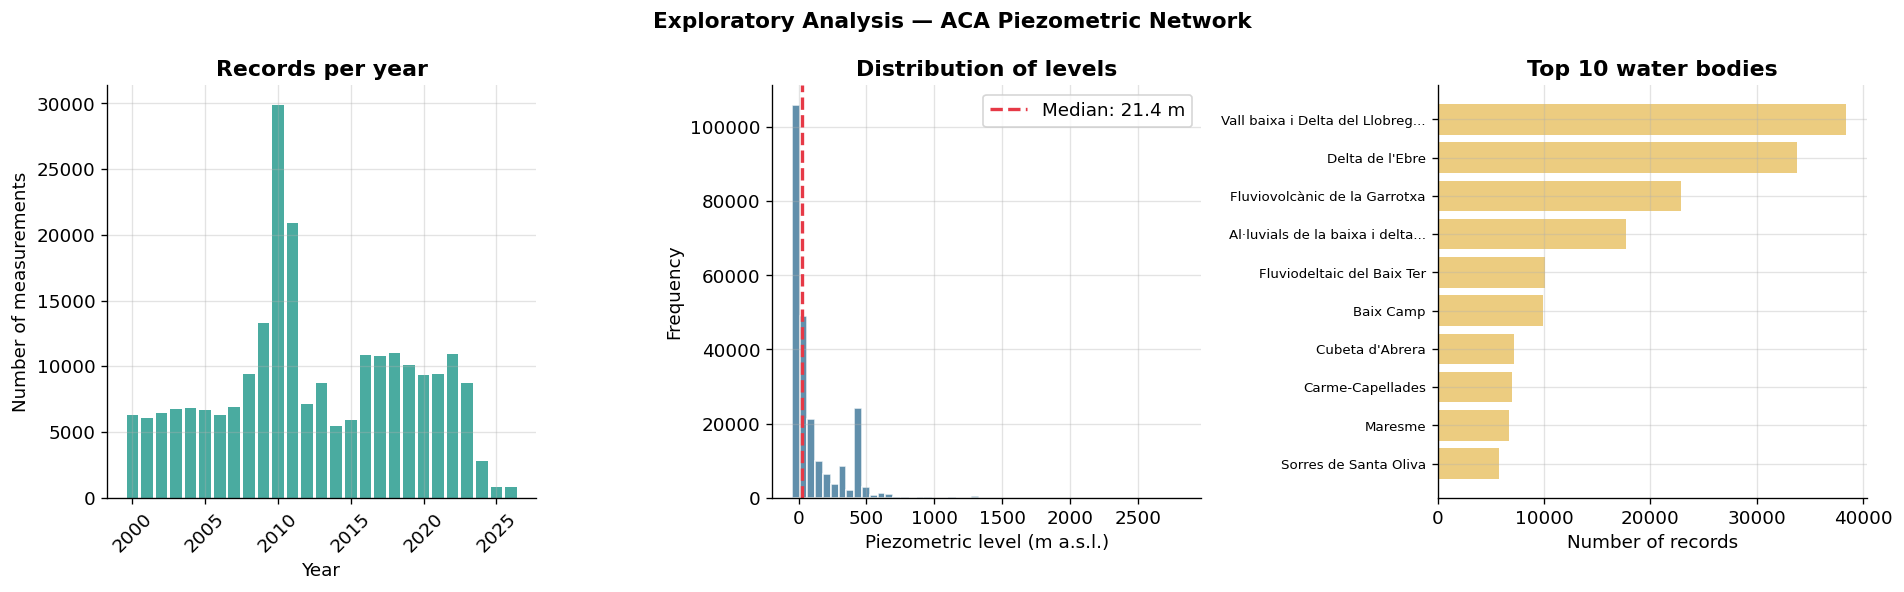

✓ Figure saved: output/01_exploratory_analysis.png


In [38]:
# ── TEMPORAL AND SPATIAL DISTRIBUTION ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

records_per_year = df.groupby('year').size()
axes[0].bar(records_per_year.index, records_per_year.values, color='#2a9d8f', alpha=0.85)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of measurements')
axes[0].set_title('Records per year', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df['level'], bins=50, color='#457b9d', alpha=0.85, edgecolor='white')
axes[1].axvline(df['level'].median(), color='#e63946', lw=2, ls='--',
                label=f'Median: {df["level"].median():.1f} m')
axes[1].set_xlabel('Piezometric level (m a.s.l.)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of levels', fontweight='bold')
axes[1].legend()

top_water_bodies = df['water_body'].value_counts().head(10)
axes[2].barh(range(len(top_water_bodies)), top_water_bodies.values, color='#e9c46a', alpha=0.85)
axes[2].set_yticks(range(len(top_water_bodies)))
axes[2].set_yticklabels([m[:30] + '...' if len(m) > 30 else m for m in top_water_bodies.index], fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('Number of records')
axes[2].set_title('Top 10 water bodies', fontweight='bold')

fig.suptitle('Exploratory Analysis — ACA Piezometric Network', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '01_exploratory_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: output/01_exploratory_analysis.png')

---
## 4. Temporal Trend Analysis

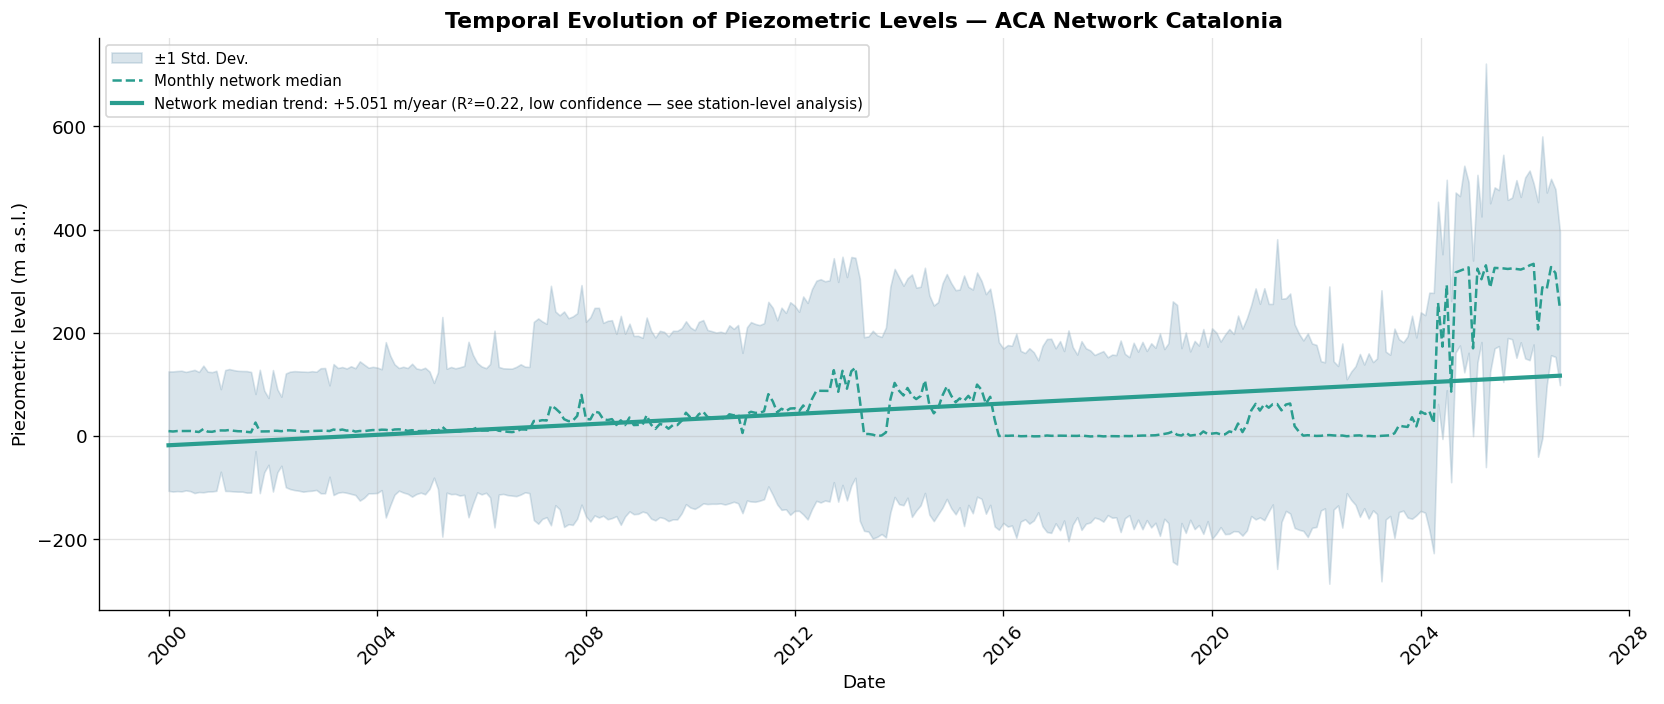

✓ Figure saved: output/02_overall_trend.png

Overall network trend: +5.0509 m/year
p-value: 0.0000 → statistically significant


In [39]:
# ── OVERALL NETWORK TREND ──────────────────────────────────────────────────────
monthly_trend = (
    df.groupby(df['date'].dt.to_period('M'))['level']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)
monthly_trend['date'] = monthly_trend['date'].dt.to_timestamp()
monthly_trend = monthly_trend[monthly_trend['count'] >= 5]

x_num = (monthly_trend['date'] - monthly_trend['date'].min()).dt.days
slope, intercept, r_val, p_val, _ = linregress(x_num, monthly_trend['median'])
linear_trend = slope * x_num + intercept
annual_trend = slope * 365

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(
    monthly_trend['date'],
    monthly_trend['median'] - monthly_trend['std'],
    monthly_trend['median'] + monthly_trend['std'],
    alpha=0.2, color='#457b9d', label='±1 Std. Dev.'
)
ax.plot(monthly_trend['date'], monthly_trend['median'],
        color='#2a9d8f', lw=1.5, ls='--', label='Monthly network median')

trend_color = '#e63946' if annual_trend < 0 else '#2a9d8f'
ax.plot(monthly_trend['date'], linear_trend,
        color=trend_color, lw=2.5,
        label=f'Network median trend: {annual_trend:+.3f} m/year (R²={r_val**2:.2f}, low confidence — see station-level analysis)')

ax.set_xlabel('Date')
ax.set_ylabel('Piezometric level (m a.s.l.)')
ax.set_title('Temporal Evolution of Piezometric Levels — ACA Network Catalonia', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '02_overall_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: output/02_overall_trend.png')
print(f'\nOverall network trend: {annual_trend:+.4f} m/year')
print(f'p-value: {p_val:.4f} → {"statistically significant" if p_val < 0.05 else "not significant"}')

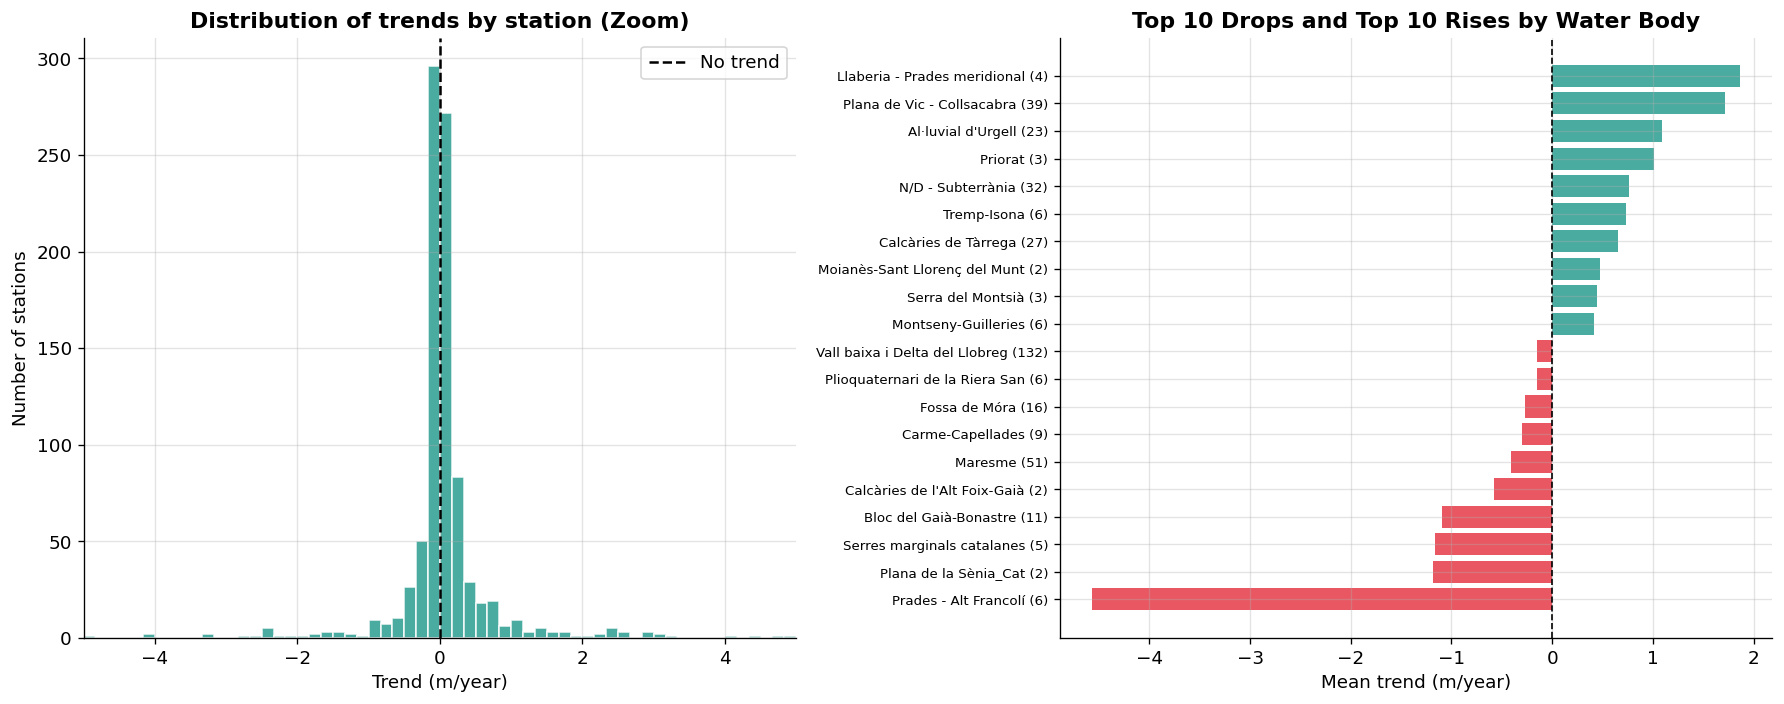

✓ Figure saved: output/03_trend_distribution.png


In [40]:
# ── TREND BY INDIVIDUAL STATION ───────────────────────────────────────────────
def compute_trend(group):
    group = group.sort_values('date').dropna(subset=['level'])
    if len(group) < 10: return None
    x = (group['date'] - group['date'].min()).dt.days
    y = group['level']
    slope, intercept, r_val, p_val, _ = linregress(x, y)
    return pd.Series({
        'trend_m_year': slope * 365,
        'r2': r_val ** 2,
        'p_value': p_val,
        'n_measurements': len(group),
        'mean_level': group['level'].mean(),
        'range_m': group['level'].max() - group['level'].min(),
        'start_year': group['date'].min().year,
        'end_year': group['date'].max().year,
        'x': group['x'].iloc[0],
        'y': group['y'].iloc[0],
        'water_body': group['water_body'].iloc[0],
    })

station_trends = df.groupby('station').apply(compute_trend).dropna().reset_index()
station_trends.to_csv(os.path.join(output_dir, 'station_trends_summary.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(station_trends['trend_m_year'], bins=60, range=(-5, 5), color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', lw=1.5, ls='--', label='No trend')
axes[0].set_xlim(-5, 5)
axes[0].set_xlabel('Trend (m/year)')
axes[0].set_ylabel('Number of stations')
axes[0].set_title('Distribution of trends by station (Zoom)', fontweight='bold')
axes[0].legend()

trend_by_water_body = station_trends.groupby('water_body')['trend_m_year'].agg(['mean', 'count'])
trend_by_water_body = trend_by_water_body[trend_by_water_body['count'] >= 2]
top_drops = trend_by_water_body.sort_values('mean').head(10)
top_rises = trend_by_water_body.sort_values('mean').tail(10)
extreme_water_bodies = pd.concat([top_drops, top_rises]).sort_values('mean')

colors_bar = ['#e63946' if v < 0 else '#2a9d8f' for v in extreme_water_bodies['mean']]
axes[1].barh(range(len(extreme_water_bodies)), extreme_water_bodies['mean'], color=colors_bar, alpha=0.85)
axes[1].set_yticks(range(len(extreme_water_bodies)))
axes[1].set_yticklabels([f"{m[:30]} ({n})" for m, n in zip(extreme_water_bodies.index, extreme_water_bodies['count'])], fontsize=8)
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('Mean trend (m/year)')
axes[1].set_title('Top 10 Drops and Top 10 Rises by Water Body', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '03_trend_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: output/03_trend_distribution.png')

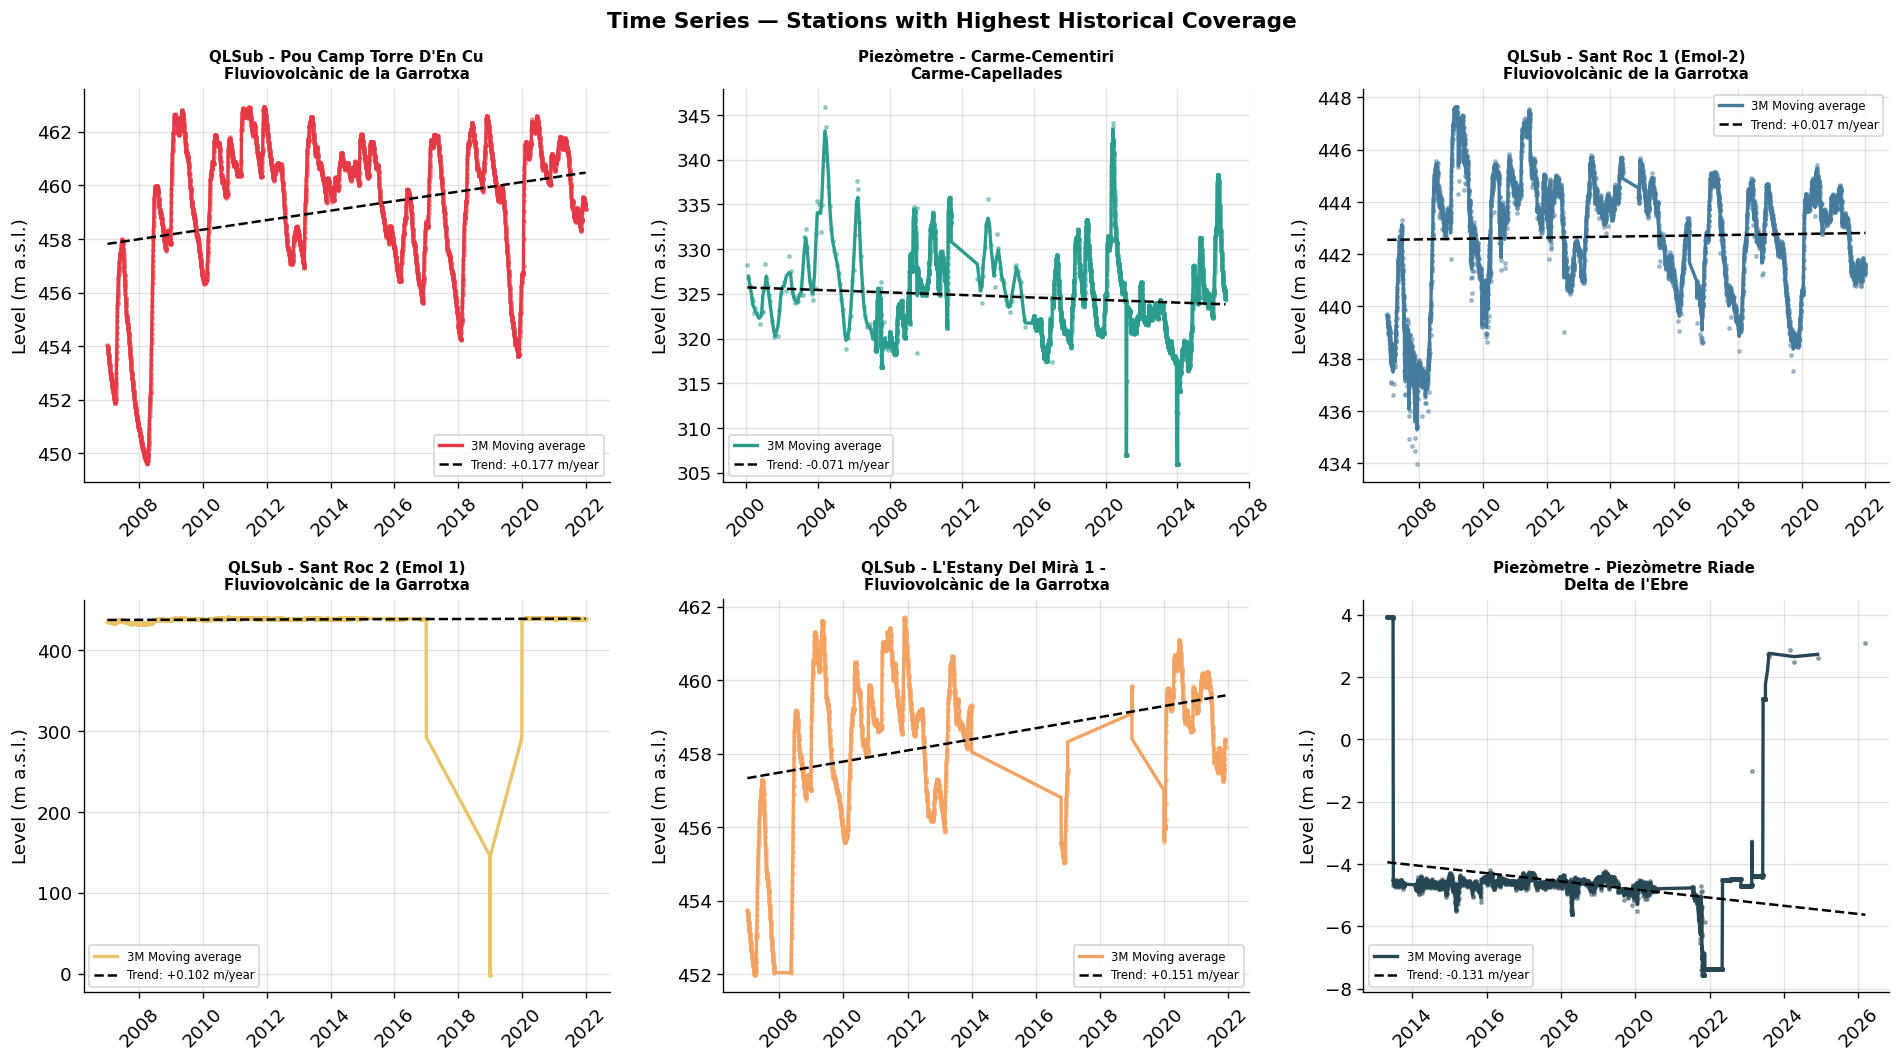

✓ Figure saved: output/04_time_series.png


In [41]:
# ── TIME SERIES FOR MAIN STATIONS ─────────────────────────────────────────────
top_stations = df.groupby('station').size().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = ['#e63946', '#2a9d8f', '#457b9d', '#e9c46a', '#f4a261', '#264653']

for i, station in enumerate(top_stations):
    station_data = df[df['station'] == station].sort_values('date')
    water_body = station_data['water_body'].iloc[0]
    
    station_data = station_data.set_index('date')
    smoothed = station_data['level'].rolling(window=3, center=True).mean()
    
    x_num = (station_data.index - station_data.index.min()).days
    slope, intercept, r_val, _, _ = linregress(x_num, station_data['level'])
    station_trend = slope * 365
    trend_line = slope * x_num + intercept

    color = palette[i]
    axes[i].plot(station_data.index, station_data['level'], 'o', ms=2, alpha=0.4, color=color)
    axes[i].plot(station_data.index, smoothed, '-', lw=2, color=color, label='3M Moving average')
    axes[i].plot(station_data.index, trend_line, '--k', lw=1.5, label=f'Trend: {station_trend:+.3f} m/year')

    axes[i].set_title(f'{station[:30]}\n{water_body[:30]}', fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Level (m a.s.l.)')
    axes[i].legend(fontsize=7)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)

fig.suptitle('Time Series — Stations with Highest Historical Coverage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '04_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: output/04_time_series.png')

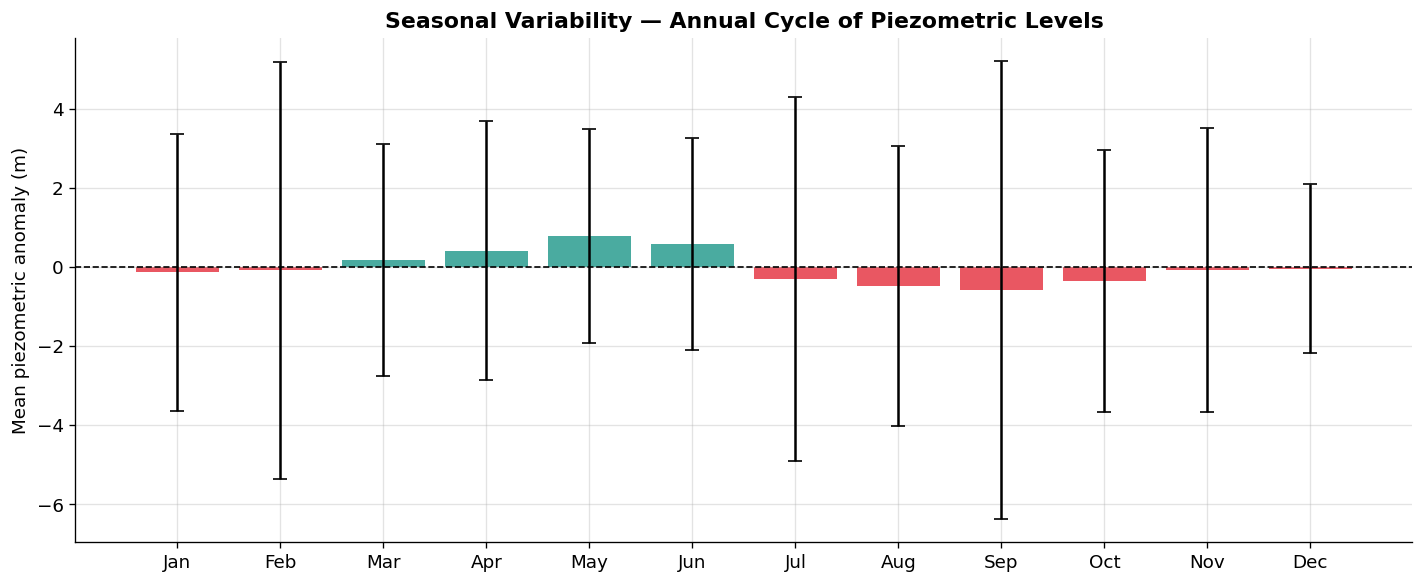

✓ Figure saved: output/05_seasonality.png


In [42]:
# ── SEASONAL VARIABILITY ───────────────────────────────────────────────────────
df_seasonal = df.copy()
station_mean = df_seasonal.groupby('station')['level'].transform('mean')
df_seasonal['anomaly'] = df_seasonal['level'] - station_mean
seasonal = df_seasonal.groupby('month')['anomaly'].agg(['mean', 'std'])
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
month_colors = ['#2a9d8f' if v >= 0 else '#e63946' for v in seasonal['mean']]
ax.bar(range(1, 13), seasonal['mean'], color=month_colors, alpha=0.85, yerr=seasonal['std'] / 2, capsize=4)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_ylabel('Mean piezometric anomaly (m)')
ax.set_title('Seasonal Variability — Annual Cycle of Piezometric Levels', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '05_seasonality.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: output/05_seasonality.png')

---
## 5. Interactive Folium Map

In [43]:
# ── INTERACTIVE MAP WITH CLUSTERS AND LAYERS ───────────────────────────────────
try:
    import pyproj
    transformer = pyproj.Transformer.from_crs('EPSG:25831', 'EPSG:4326', always_xy=True)
    lon, lat = transformer.transform(station_trends['x'].values, station_trends['y'].values)
    station_trends['lat'], station_trends['lon'] = lat, lon
except ImportError:
    station_trends['lat'] = (station_trends['y'] - 4500000) / 111320 + 40.5
    station_trends['lon'] = (station_trends['x'] - 350000) / (111320 * 0.766) + 2.0

mask = (station_trends['lat'] > 40.0) & (station_trends['lat'] < 43.0) & (station_trends['lon'] > 0.0) & (station_trends['lon'] < 4.0)
station_trends_map = station_trends[mask].copy()

mapa = folium.Map(location=[41.8, 1.8], zoom_start=8, tiles='OpenStreetMap', name='Light Map')

def trend_color(trend):
    if trend < -0.5: return '#d62728'
    elif trend < -0.1: return '#ff7f0e'
    elif trend < 0.1: return '#bcbd22'
    elif trend < 0.5: return '#2ca02c'
    else: return '#1f77b4'

group_negative = folium.FeatureGroup(name='🔴 Negative Trends (Drop)')
cluster_negative = MarkerCluster().add_to(group_negative)

group_positive = folium.FeatureGroup(name='🟢 Positive/Stable Trends (Rise)')
cluster_positive = MarkerCluster().add_to(group_positive)

for _, row in station_trends_map.iterrows():
    color = trend_color(row['trend_m_year'])
    popup_html = f"<div style='font-family: Arial; width: 200px;'><b>{row['station']}</b><br>Trend: {row['trend_m_year']:+.3f} m/year</div>"
    
    marker = folium.CircleMarker(
        location=[row['lat'], row['lon']], radius=6, color='white', weight=1,
        fill=True, fill_color=color, fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=220)
    )
    
    if row['trend_m_year'] < 0:
        marker.add_to(cluster_negative)
    else:
        marker.add_to(cluster_positive)

group_negative.add_to(mapa)
group_positive.add_to(mapa)
folium.LayerControl(collapsed=False).add_to(mapa)

# Add Title to Map
title_html = '''
<div style="position: fixed; top: 15px; left: 50px; width: 380px; height: 45px; 
    background-color: white; border: 2px solid grey; z-index:9999; font-size:15px; 
    font-weight: bold; text-align: center; line-height: 45px; border-radius: 5px; box-shadow: 2px 2px 5px rgba(0,0,0,0.3);">
    ACA Piezometric Network - Trends Map
</div>
'''
mapa.get_root().html.add_child(folium.Element(title_html))

# Add Legend to Map
legend_html = '''
<div style="position: fixed; bottom: 30px; right: 30px; width: 220px; height: 160px; 
    background-color: white; border: 2px solid grey; z-index:9999; font-size:12px; 
    padding: 10px; border-radius: 5px; box-shadow: 2px 2px 5px rgba(0,0,0,0.3);">
    <b>Piezometric Trend (m/year)</b><br>
    <i style="background:#d62728;width:15px;height:15px;float:left;margin-right:8px;border-radius:50%;"></i> < -0.5 (Severe Drop)<br>
    <i style="background:#ff7f0e;width:15px;height:15px;float:left;margin-right:8px;border-radius:50%;"></i> -0.5 to -0.1 (Moderate Drop)<br>
    <i style="background:#bcbd22;width:15px;height:15px;float:left;margin-right:8px;border-radius:50%;"></i> -0.1 to 0.1 (Stable)<br>
    <i style="background:#2ca02c;width:15px;height:15px;float:left;margin-right:8px;border-radius:50%;"></i> 0.1 to 0.5 (Moderate Rise)<br>
    <i style="background:#1f77b4;width:15px;height:15px;float:left;margin-right:8px;border-radius:50%;"></i> > 0.5 (Significant Rise)<br>
</div>
'''
mapa.get_root().html.add_child(folium.Element(legend_html))

mapa.save(os.path.join(output_dir, 'piezometric_network_Catalonia.html'))
print('✓ Interactive clustered & layered map successfully saved.')

✓ Interactive clustered & layered map successfully saved.


---
## 6. Summary and Conclusions

In [44]:
# ── FINAL SUMMARY TABLE ────────────────────────────────────────────────────────
mean_station_trend = station_trends['trend_m_year'].mean()
median_station_trend = station_trends['trend_m_year'].median()

summary_table = pd.DataFrame({
    'Metric': [
        'Total Raw Records',
        'Clean Valid Records',
        'Total Piezometers Analyzed',
        'Network Median Level (m a.s.l.)',
        'Overall Annual Trend (Median, Station-Level)',
        'Stations with Negative Trend',
        'Stations with Positive Trend'
    ],
    'Value': [
        f"{len(df_raw):,}",
        f"{len(df):,}",
        f"{len(station_trends):,}",
        f"{df['level'].median():.2f} m",
        f"{median_station_trend:+.4f} m/year",
        f"{(station_trends['trend_m_year'] < 0).sum()} ({(station_trends['trend_m_year'] < 0).mean() * 100:.1f}%)",
        f"{(station_trends['trend_m_year'] >= 0).sum()} ({(station_trends['trend_m_year'] >= 0).mean() * 100:.1f}%)"
    ]
})

print('\n' + '='*50)
print(' ACA PIEZOMETRIC ANALYSIS SUMMARY')
print('='*50)
print(summary_table.to_string(index=False))
print('='*50)
print(f"All generated files have been saved in: {output_dir}")


 ACA PIEZOMETRIC ANALYSIS SUMMARY
                                      Metric          Value
                           Total Raw Records        244,114
                         Clean Valid Records        238,330
                  Total Piezometers Analyzed            912
             Network Median Level (m a.s.l.)        21.41 m
Overall Annual Trend (Median, Station-Level) +0.0050 m/year
                Stations with Negative Trend    431 (47.3%)
                Stations with Positive Trend    481 (52.7%)
All generated files have been saved in: c:\Users\cadam\Documents\Phyton\ACA-PiezometryCatalunya\output


---
## 7. Discussion and Interpretation

### Quantitative Overview and Network Scale
The analysis of the ACA monitoring system across **907 total piezometers analyzed** from a robust raw volume of **243969 records** (**238186 valid cleaned records**) provides a comprehensive macro-scale view of Catalonia's underground water storage. With a network median level situated at **21.4 m above sea level**, the baseline distribution captures the transition from high-altitude inland recharge zones to low-lying coastal alluvial discharge systems.

### Spatial Patterns of Piezometric Trends
The spatial distribution of trends mapped through the interactive Folium viewer reveals a complex spatial pattern characterized by a delicate balance and pronounced local polarizations. The network as a whole appears essentially stable at the aggregate level, with a median station-level trend of only +0.005 m/year, a figure far more robust than a simple regression on the network-wide monthly median, which is disproportionately skewed by a handful of outlier stations and by changes in station composition over time. However, this apparent overall stability masks sharp local divergence: the station-by-station breakdown shows 431 stations (47.3%) exhibit a negative trend, while 481 stations (52.7%) show a positive trend. This near 50/50 split reveals that behind a stable network median, nearly half of Catalonia's monitored points remain under severe quantitative pressure (< -0.5 m/year), pointing toward localized structural overexploitation or vulnerability to prolonged meteorological droughts.

### Hydrogeological Inertia and Climate Drivers
Groundwater levels act as a smoothed, integrated response to climatic variability. Unlike surface water bodies or reservoir storage (which react rapidly to episodic intense rainfall) piezometric levels display a marked hydrogeological inertia. The downward trajectories captured in nearly half of the stations reflect cumulative deficits in natural recharge, exacerbated by structural pumping exceeding the sustainable yield of those specific aquifers.

### Seasonality and Management Implications
The seasonal anomaly composite highlights a robust cyclical pattern characterized by negative anomalies during late summer and early autumn (driven by peak irrigation extraction and high evapotranspiration rates) and a subsequent rebound towards positive anomalies in late winter/spring. Understanding this exact intra-annual window is vital for the Catalan Water Agency (ACA) to optimize monitoring frequencies, enforce dynamic abstraction controls, and plan non-conventional water integration before critical depletion thresholds are breached.

---

## References

* Agència Catalana de l'Aigua (ACA). (2024). *Nivell piezomètric de les aigües subterrànies de Catalunya*. Generalitat de Catalunya — Open Data.
* Agència Catalana de l'Aigua (ACA). (2020). *Pla especial d'actuació en situació d'alerta i eventual sequera (PES)*. Generalitat de Catalunya.